### 1. Importar as bibliotecas

In [64]:
# Importação das bibliotecas que utilizaremos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy.stats import variation
import numpy as np

### 2. Definir a variável "file" pelo nome da planilha.

In [3]:
# Importação do arquivo de tabela a ser utilizado, através do path na seção "Files" do Colab, contendo as informações de resíduos sólidos
file='./Solid_waste_pt.xlsx'

### 3. Ler a planilha no Python.

In [4]:
# Visão geral da tabela
df=pd.read_excel(file)
df

,Regiao_Coleta,Tipo_Residuo,Origem_Residuo,Metodo_Destinacao,Massa_Coletada_kg,Densidade_Residuo_kgm3,Umidade_Residuo_pct,Distancia_Destinacao_km,Custo_Coleta_Transporte_RS_ton,Indice_Reciclabilidade_pct,Poder_Calorifico_MJkg
0,Zona Sul,Reciclável,Comercial,Aterro Sanitário,1057.3,80.8,2.0,14.7,138.7,79.7,15.1
1,Zona Oeste,Reciclável,Comercial,Reciclagem,533.3,82.4,2.0,9.1,119.1,85.4,17.9
2,Centro,Reciclável,Comercial,Reciclagem,529.7,72.7,2.0,24.0,223.2,81.6,13.9
3,Zona Oeste,Reciclável,Comercial,Reciclagem,486.3,67.4,2.0,3.6,117.9,82.0,18.8
4,Zona Leste,Reciclável,Comercial,Aterro Sanitário,527.1,40.0,2.0,16.7,164.2,88.0,14.7
...,...,...,...,...,...,...,...,...,...,...,...
285,Zona Leste,Orgânico,Residencial,Aterro Sanitário,275.9,371.8,77.0,17.2,178.8,5.2,6.5
286,Zona Norte,Orgânico,Comercial,Aterro Sanitário,471.8,338.4,77.2,52.9,262.3,5.0,8.1
287,Zona Leste,Orgânico,Residencial,Aterro Sanitário,356.3,341.2,77.6,18.0,184.2,10.1,3.6
288,Zona Oeste,Orgânico,Comercial,Reciclagem,674.9,316.9,78.5,5.1,94.1,8.1,8.8


In [5]:
# Distribuicao de frequencia absoluta em classes de mesma amplitude
# (intervalos fechados a esquerda e abertos a direita: [a, b))
classes = range(0,125,25)
coluna = 'Umidade_Residuo_pct'
frequencia_pct_umidade = pd.cut(x=df[coluna], bins=classes, include_lowest=True, right=False).value_counts().sort_index()
frequencia_pct_umidade

,count
Umidade_Residuo_pct,
"[0, 25)",121
"[25, 50)",50
"[50, 75)",110
"[75, 100)",9


In [6]:
# Frequencia relativa percentual de cada classe
# frequencia_relativa_pct_umidade = round(pd.cut(x=df[coluna], bins=classes, include_lowest=True, right=False).value_counts(normalize=True).sort_index() * 100, 2)
# frequencia_relativa_pct_umidade

### 4. Comando "Describe" da biblioteca Pandas
Este comando gera estatísticas descritivas que incluem aquelas que resumem a tendência central, a dispersão e a distribuição de um conjunto de dados.

As informações trazidas por esse comando abrangem:
  - **Contagem total de registros (count)**: como obtido anteriormente na Sprint 1, nossa base de dados possui **290 registros no total**.
  - **Média dos registros (mean)**: como obtido anteriormente, a média de teor de umidade dos 290 registros é definida por esse comando, no qual obtemos um **teor médio de 37.01%**.
  - std = desvio padrão
  - **Valor mínimo (min)**: editar depois....
  - max = valor máximo:  editar depois....

  Nessa Sprint, um dos nossos objetivos é estudar uma forma de classificar nosso conjunto de registros em subconjuntos, os quais denominaremos como **separatrizes**. O **quartil** foi o tipo de separatriz que escolhemos analisar.

  O próprio comando *describe*

In [7]:
#comando describe mostra várias medidas das variáveis quantitativas, incluindo média e mediana.
df.Umidade_Residuo_pct.describe().round(2)

,Umidade_Residuo_pct
count,290.00
mean,37.01
std,25.23
min,2.00
25%,13.92
50%,32.30
75%,62.12
max,81.60


In [45]:
Q1 = df.Umidade_Residuo_pct.quantile(0.25).round(2)
Q1

np.float64(13.92)

In [46]:
Q2 = df.Umidade_Residuo_pct.quantile(0.5).round(2)
Q2

np.float64(32.3)

In [47]:
Q3 = df.Umidade_Residuo_pct.quantile(0.75).round(2)
Q3

np.float64(62.12)

### 5. Boxplot para uma variável

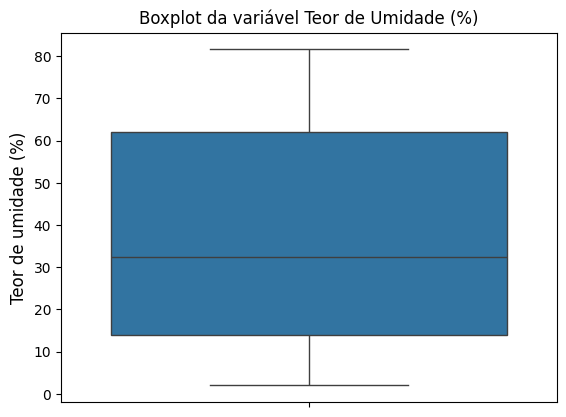

In [10]:
sns.boxplot(data=df.Umidade_Residuo_pct, orient='v')
plt.ylabel('Teor de umidade (%)', fontsize=12)
plt.title('Boxplot da variável Teor de Umidade (%)', fontsize=12)
plt.show()


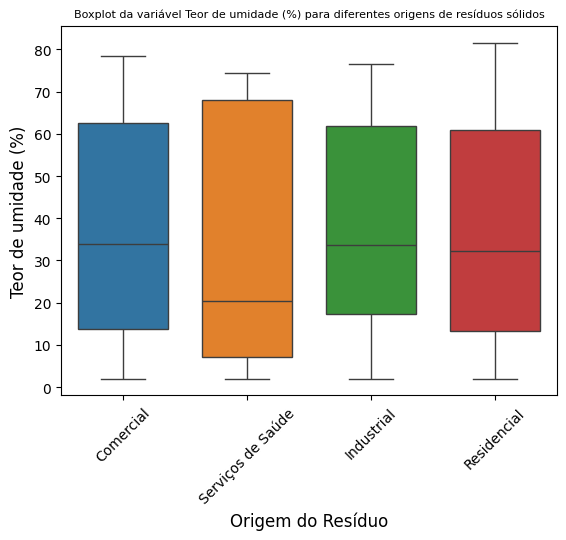

In [55]:
sns.boxplot(data=df, x='Origem_Residuo', y='Umidade_Residuo_pct', hue='Origem_Residuo', fill=True, gap=.1)
plt.xlabel('Origem do Resíduo', fontsize=12)
plt.ylabel('Teor de umidade (%)', fontsize=12)
plt.title('Boxplot da variável Teor de umidade (%) para diferentes origens de resíduos sólidos', fontsize=8)
plt.xticks(rotation=45)
plt.show()

### 6. Outliers
Método para identificar outliers.

**Método do boxplot (ou Método de Tukey)**

Cálculo dos limites inferior (linf) e superior (lsup) para identificação dos *outliers*.

In [37]:
AIQ = Q3 - Q1

np.float64(48.2)

Cálculo dos limites inferior e superior

In [44]:
linf = Q1 - 1.5 * AIQ
lsup = Q3 + 1.5 * AIQ
print(f"linf: {linf.round(2)} %")
print(f"lsup: {lsup.round(2)} %")

linf: -58.38%
lsup: 134.43%


Visualizando os outliers superiores.

In [29]:
# Obtendo outliers superiores
df[df.Umidade_Residuo_pct > lsup]

,Regiao_Coleta,Tipo_Residuo,Origem_Residuo,Metodo_Destinacao,Massa_Coletada_kg,Densidade_Residuo_kgm3,Umidade_Residuo_pct,Distancia_Destinacao_km,Custo_Coleta_Transporte_RS_ton,Indice_Reciclabilidade_pct,Poder_Calorifico_MJkg


In [31]:
# Obtendo outliers inferiores
df[df.Umidade_Residuo_pct < linf]

,Regiao_Coleta,Tipo_Residuo,Origem_Residuo,Metodo_Destinacao,Massa_Coletada_kg,Densidade_Residuo_kgm3,Umidade_Residuo_pct,Distancia_Destinacao_km,Custo_Coleta_Transporte_RS_ton,Indice_Reciclabilidade_pct,Poder_Calorifico_MJkg


## Desvio Padrão

AMOSTRAL

In [61]:
std_Teor_Umidade = round(df.Umidade_Residuo_pct.std(ddof=0), 2)
print(f"O desvio padrão para análise amostral é de {std_Teor_Umidade}")

O desvio padrão é de 25.19


POPULACIONAL

In [62]:
std_Teor_Umidade = round(df.Umidade_Residuo_pct.std(ddof=1), 2)
print(f"O desvio padrão para análise populacional é de {std_Teor_Umidade}")

O desvio padrão é de 25.23


## Coeficiente de variação

AMOSTRAL

In [67]:
# coeficiente de variação (amostral)
round(scipy.stats.variation(df.Umidade_Residuo_pct, ddof=1)*100, 2)

np.float64(68.18)

POPULACIONAL

In [68]:
# coeficiente de variação (populacional)
round(scipy.stats.variation(df.Umidade_Residuo_pct, ddof=0)*100, 2)

np.float64(68.07)